In [ ]:
%pip install langchain langchain-openai langchain-chroma chromadb pypdf tiktoken

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os

os.environ["OPENAI_API_KEY"] = "sk-*************************"
os.environ["OPENAI_BASE_URL"] = "https://dashscope.aliyuncs.com/compatible-mode/v1"
os.environ["OPENAI_MODEL"] = "qwen-turbo"
os.environ["EMBEDDING_MODEL"] = "text-embedding-v4"

In [4]:
import getpass

# 导入核心库
import os
from uuid import uuid4

import chromadb
from langchain_chroma import Chroma

# 导入LangChain相关模块
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# --- 环境配置 ---
# 优雅地处理API密钥，如果环境变量中没有，则提示用户输入
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("请输入您的OpenAI API密钥: ")

print("环境配置完成，OpenAI API密钥已设置。")

环境配置完成，OpenAI API密钥已设置。


In [5]:
PDF_PATH = "docs/中华人民共和国民法典.pdf"
# 使用PyPDFLoader加载文档
try:
    if PDF_PATH.endswith(".pdf"):
        loader = PyPDFLoader(PDF_PATH)
        documents = loader.load()
        print(f"成功加载 {len(documents)} 页文档。")
    else:  # 备用方案
        from langchain_community.document_loaders import TextLoader

        loader = TextLoader(PDF_PATH, encoding="utf-8")
        documents = loader.load()
        print(f"成功加载文本文档。")

except Exception as e:
    print(f"加载文档时出错: {e}")
    documents = []  # 确保documents被定义

# --- 2. 切分文档 ---
if documents:
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,  # 每个块的目标大小（字符数）
        chunk_overlap=50,  # 相邻块之间的重叠字符数
        length_function=len,
        is_separator_regex=False,
    )

    chunks = text_splitter.split_documents(documents)
    print(f"文档被成功切分为 {len(chunks)} 个块。")
    # 打印第一个块作为示例
    print("\n--- 第一个文本块示例 ---")
    print(chunks[0].page_content)
    print("------------------------")
else:
    print("未能加载文档，无法进行切分。")
    chunks = []

成功加载 231 页文档。
文档被成功切分为 405 个块。

--- 第一个文本块示例 ---
1
中华人民共和国民法典
发文单位：全国人民代表大会常务委员会
文    号：中华人民共和国主席令第四十五号
效力范围：全文有效
发文日期：2020-05-28
生效日期：2021-01-01
　　《中华人民共和国民法典》已由中华人民共和国第十三届全国人
民代表大会第三次会议于 2020 年 5 月 28 日通过，现予公布，自 2021
年 1 月 1 日起施行。
　　                                                                                                          
中华人民共和国主席  习近平
　　2020 年 5 月 28 日
中华人民共和国民法典
(2020 年5 月 28 日第十三届全国人民代表大会第三次会议通过)
　　目  录
------------------------


In [6]:
pip install langchain-community dashscope

Note: you may need to restart the kernel to use updated packages.


In [7]:
from langchain_community.embeddings import DashScopeEmbeddings

embeddings = DashScopeEmbeddings(
    model="text-embedding-v4",  # 或 text-embedding-v2
    dashscope_api_key=os.getenv("OPENAI_API_KEY"),
)
# 测试一下嵌入功能
test_vector = embeddings.embed_query("这是一个测试句子。")
print(f"测试向量维度: {len(test_vector)}")
print(f"测试向量前5个值: {test_vector[:5]}")

测试向量维度: 1024
测试向量前5个值: [-0.042264748364686966, -0.018784333020448685, 0.012466673739254475, -0.014217975549399853, -0.011701290495693684]


In [8]:
# --- 4. 初始化ChromaDB并进行向量化存储 ---
if chunks and embeddings:
    # 定义一个持久化目录，用于存储向量数据
    persist_directory = "chroma_db_rag_tutorial"

    # 如果目录已存在，先清空，确保每次运行都是全新的开始
    if os.path.exists(persist_directory):
        import shutil

        shutil.rmtree(persist_directory)
        print(f"已清空旧的数据库目录: {persist_directory}")

    print("\n正在创建向量数据库并存储文档...")

    # 使用Chroma.from_documents一步完成向量化和存储
    # 这是最便捷的方式，LangChain会在后台处理所有事情
    vector_store = Chroma.from_documents(
        documents=chunks,  # 我们之前切分好的文档块
        embedding=embeddings,  # 我们初始化的嵌入模型
        persist_directory=persist_directory,  # 指定持久化目录
    )

    print(f"成功将 {vector_store._collection.count()} 个向量存入ChromaDB。")
    print(f"数据库已持久化到目录: {persist_directory}")
else:
    print("缺少文本块或嵌入模型，无法创建向量数据库。")
    vector_store = None

已清空旧的数据库目录: chroma_db_rag_tutorial

正在创建向量数据库并存储文档...
成功将 405 个向量存入ChromaDB。
数据库已持久化到目录: chroma_db_rag_tutorial


In [10]:
# --- 5. 执行相似度搜索 ---
if vector_store:
    query = "民法典是什么时候颁布的"
    print(f"\n--- 正在执行相似度搜索，查询: '{query}' ---")

    # 使用similarity_search方法进行检索，k=2表示返回最相关的2个结果
    retrieved_docs = vector_store.similarity_search(query, k=2)

    print(f"检索到 {len(retrieved_docs)} 个相关文档块：")
    for i, doc in enumerate(retrieved_docs):
        print(f"\n--- 相关文档 {i+1} ---")
        print(doc.page_content)
        print(
            f"来源: {doc.metadata.get('source', 'N/A')}, 页码: {doc.metadata.get('page', 'N/A')}"
        )
        print("--------------------")

    # --- 演示元数据过滤 ---
    print("\n--- 演示元数据过滤查询 ---")
    # 假设我们只想在特定来源的文档中搜索
    # 注意：在我们的简单示例中，所有块来源相同，但这是展示其能力的强大方式
    query_with_filter = "民法典里对于合同是如何定义的？"
    print(f"查询: '{query_with_filter}'，并筛选来源为 '{PDF_PATH}'")

    retrieved_with_filter = vector_store.similarity_search(
        query_with_filter, k=2, filter={"source": PDF_PATH}  # ChromaDB的元数据过滤语法
    )

    print(f"通过元数据过滤，检索到 {len(retrieved_with_filter)} 个文档块：")
    for i, doc in enumerate(retrieved_with_filter):
        print(f"\n--- 过滤后的相关文档 {i+1} ---")
        print(doc.page_content)
        print("--------------------")

else:
    print("向量数据库未成功创建，无法执行搜索。")


--- 正在执行相似度搜索，查询: '民法典是什么时候颁布的' ---
检索到 2 个相关文档块：

--- 相关文档 1 ---
1
中华人民共和国民法典
发文单位：全国人民代表大会常务委员会
文    号：中华人民共和国主席令第四十五号
效力范围：全文有效
发文日期：2020-05-28
生效日期：2021-01-01
　　《中华人民共和国民法典》已由中华人民共和国第十三届全国人
民代表大会第三次会议于 2020 年 5 月 28 日通过，现予公布，自 2021
年 1 月 1 日起施行。
　　                                                                                                          
中华人民共和国主席  习近平
　　2020 年 5 月 28 日
中华人民共和国民法典
(2020 年5 月 28 日第十三届全国人民代表大会第三次会议通过)
　　目  录
来源: docs/中华人民共和国民法典.pdf, 页码: 0
--------------------

--- 相关文档 2 ---
8
　　        第七章  环境污染和生态破坏责任
　　        第八章  高度危险责任
　　        第九章  饲养动物损害责任
　　        第十章  建筑物和物件损害责任
　　附  则
　　第一编  总    则
　　第一章  基本规定
　　第一条  为了保护民事主体的合法权益，调整民事关系，维护社
会和经济秩序，适应中国特色社会主义发展要求，弘扬社会主义核心
价值观，根据宪法，制定本法。
　　第二条  民法调整平等主体的自然人、法人和非法人组织之间的
人身关系和财产关系。
　　第三条  民事主体的人身权利、财产权利以及其他合法权益受法
律保护，任何组织或者个人不得侵犯。
　　第四条  民事主体在民事活动中的法律地位一律平等。
　　第五条  民事主体从事民事活动，应当遵循自愿原则，按照自己
的意思设立、变更、终止民事法律关系。
　　第六条  民事主体从事民事活动，应当遵循公平原则，合理确定
各方的权利和义务。
来源: docs/中华人民共和国民法典.pdf, 页码: 7
--------------------

--- 演示

In [11]:
pip install umap-learn scikit-learn plotly pandas

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install "numpy<=2.2.0"

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install umap-learn --upgrade

Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install matplotlib packaging

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 3.5 MB/s  0:00:02m 3.8 MB/s eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 5.8 MB/s  0:00:005.8 MB/s eta 0:00:01
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


正在从ChromaDB中提取所有文档和向量...
正在使用 UMAP 进行降维...


/Users/eumenides/miniforge3/envs/jupyter_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


降维完成（方法：UMAP），数据已准备好进行可视化。样本数：405

--- 生成的JSON数据（用于HTML可视化，前500字符）---
[{"x":4.8755850792,"y":2.1646399498,"content":"1\n中华人民共和国民法典\n发文单位：全国人民代表大会常务委员会\n文    号：中华人民共和国主席令第四十五号\n效力范围：全文有效\n发文日期：2020-05-28\n生效日期：2021-01-01\n　　《中华人民共和国民法典》已由中华人民共和国第十三届全国人\n民代表大会第三次会议于 2020 年 5 月 28 日通过，现予公布，自 2021\n年 1 月 1 日起施行。\n　　                                                                                                          \n中华人民共和国主席  习近平\n　　2020 年 5 月 28 日\n中华人民共和国民法典\n(2020 年5 月 28 日第十三届全国人民代表大会第三次会议通过)\n　　目  录"},{"x":4.9826288223,"y":1.7631373405,"content":"2\n　　第一编  ...


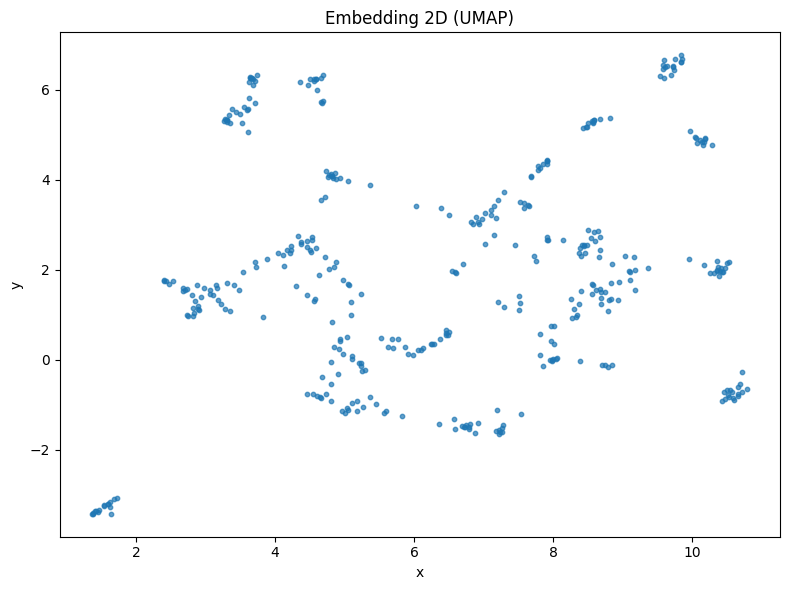

已保存静态图：embedding_2d.png


已导出交互图：embedding_2d.html


<Figure size 640x480 with 0 Axes>

In [17]:
if vector_store:
    print("正在从ChromaDB中提取所有文档和向量...")
    data = vector_store.get(include=["embeddings", "documents", "metadatas"])

    embeddings = data.get("embeddings")
    documents_content = data.get("documents")

    # 1) 基础校验
    if embeddings is not None and len(embeddings) > 1:
        import numpy as np
        import pandas as pd

        # 将列表转换为 numpy 数组
        embedding_array = np.array(embeddings)
        if embedding_array.ndim != 2:
            raise ValueError(
                f"期望二维数组 (n_samples, n_dims)，实际 ndim={embedding_array.ndim}"
            )
        if embedding_array.shape[1] < 2:
            raise ValueError(
                f"原始向量维度不足（{embedding_array.shape[1]}），无法降到 2 维。"
            )

        # 2) 优先用 UMAP，失败则回退 PCA
        embedding_2d = None
        method_used = None

        try:
            import umap  # 依赖 numba，要求 numpy<=2.2

            print("正在使用 UMAP 进行降维...")
            reducer = umap.UMAP(n_components=2, random_state=42)
            embedding_2d = reducer.fit_transform(embedding_array)
            method_used = "UMAP"
        except Exception as e:
            print(f"UMAP 失败，自动回退 PCA。原因：{e}")
            try:
                from sklearn.decomposition import PCA
            except ImportError:
                raise ImportError(
                    "未安装 scikit-learn，无法使用 PCA 回退。请先安装：pip install scikit-learn"
                )
            print("正在使用 PCA 进行降维...")
            reducer = PCA(n_components=2, random_state=42)
            embedding_2d = reducer.fit_transform(embedding_array)
            method_used = "PCA"

        # 3) 生成 DataFrame
        df = pd.DataFrame(
            {
                "x": embedding_2d[:, 0],
                "y": embedding_2d[:, 1],
                "content": documents_content,
            }
        )
        print(
            f"降维完成（方法：{method_used}），数据已准备好进行可视化。样本数：{len(df)}"
        )

        # 4) 导出 JSON（供前端可视化使用）
        json_data = df.to_json(orient="records", force_ascii=False)
        print("\n--- 生成的JSON数据（用于HTML可视化，前500字符）---")
        print(json_data[:500] + "...")

        # 5) 绘图 - matplotlib 静态散点（保存 PNG）
        try:
            import matplotlib.pyplot as plt

            plt.figure(figsize=(8, 6))
            # 不指定颜色，符合“不要设置特定颜色”的规范
            plt.scatter(df["x"], df["y"], s=10, alpha=0.7)
            plt.title(f"Embedding 2D ({method_used})")
            plt.xlabel("x")
            plt.ylabel("y")
            plt.tight_layout()
            plt.show()  # 若无显示环境，这行不影响保存
            out_png = "embedding_2d.png"
            plt.savefig(out_png, dpi=150)
            print(f"已保存静态图：{out_png}")
        except Exception as e:
            print(f"[matplotlib] 绘图失败：{e}")

        # 6) 绘图 - Plotly 交互散点（保存 HTML，若已安装）
        try:
            import plotly.express as px

            fig = px.scatter(
                df,
                x="x",
                y="y",
                hover_data={"content": True, "x": False, "y": False},
                title=f"Embedding 2D ({method_used})",
            )
            fig.update_traces(marker=dict(size=6, opacity=0.8))
            fig.update_layout(margin=dict(l=10, r=10, t=40, b=10))

            try:
                fig.show()
            except Exception:
                pass

            out_html = "embedding_2d.html"
            fig.write_html(out_html, include_plotlyjs="cdn", full_html=True)
            print(f"已导出交互图：{out_html}")
        except Exception as e:
            print(
                f"[plotly] 绘图或导出失败（可忽略）：{e}；如需交互图，请先安装：pip install plotly"
            )

    else:
        print("数据库中的向量数量不足，无法进行可视化。")
else:
    print("向量数据库未初始化，无法进行可视化。")

[matplotlib] 绘图失败：No module named 'matplotlib'
